<a href="https://colab.research.google.com/github/poojakofficialdocs-lgtm/python-data-analytics-project/blob/main/Job_Market_Data_Analysis_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PART 1 **EXPLORATORY DATA ANALYSIS**

In [2]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/3.25k [00:00<?, ?B/s]

data_jobs.csv:   0%|          | 0.00/231M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

**FILTER USA DATA ANALYST ROLES**

In [3]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')]

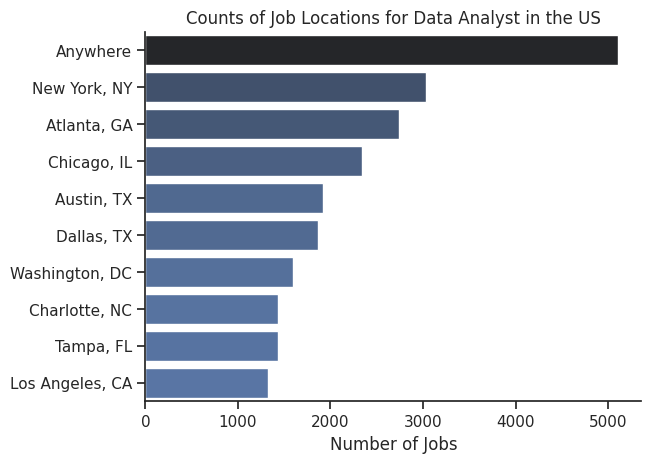

In [9]:
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')

sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r',legend=False)
sns.despine()
plt.title('Counts of Job Locations for Data Analyst in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

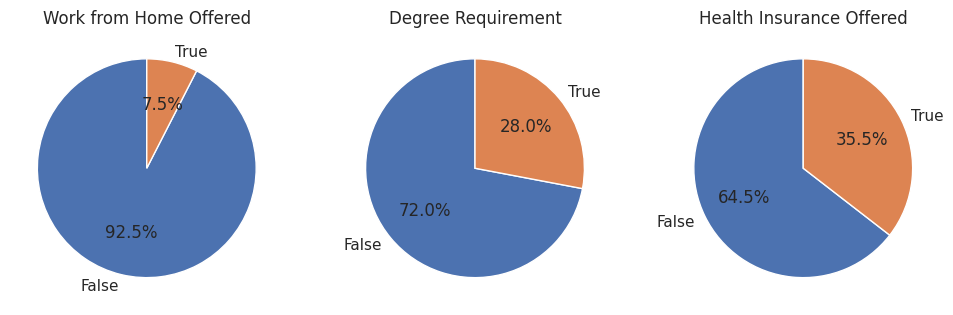

In [10]:
# rewrite the above with a for loop
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3)
fig.set_size_inches((12, 5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_US[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

# plt.suptitle('Benefit Analysis of Data Jobs', fontsize=16)
plt.show()

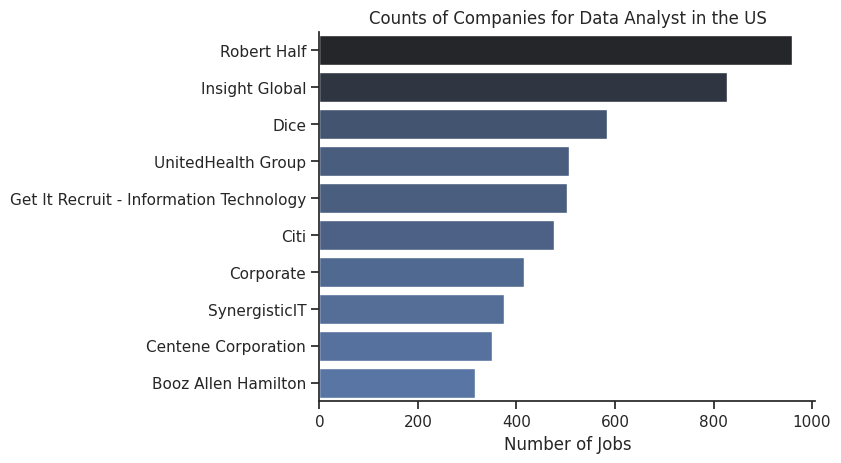

In [12]:
df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Companies for Data Analyst in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

# **PART-2 PROJECT SKILL DEMAND**

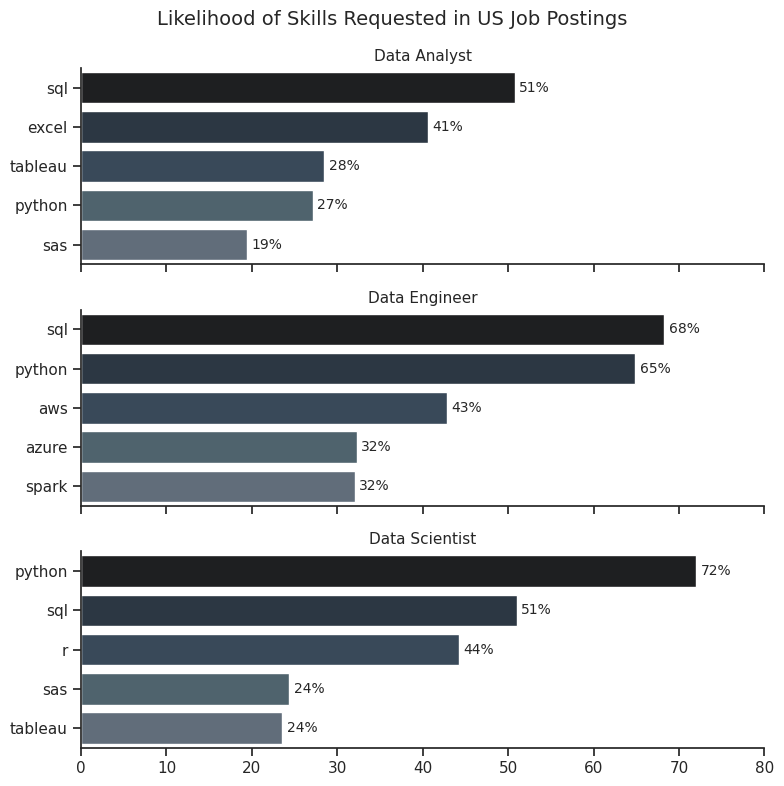

In [15]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Filter the main dataframe for US jobs in the top 3 roles
target_roles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
df_us_roles = df[(df['job_country'] == 'United States') & (df['job_title_short'].isin(target_roles))].copy()

# 2. Setup the Plot Grid
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=14, y=0.98)
sns.set_theme(style='ticks')

# Custom dark-to-blue gradient palette matching the image style
colors = ['#1d1f21', '#283747', '#34495e', '#4a6572', '#5d6d7e']

# 3. Loop through each role and dynamically compute percentages from df
for i, role in enumerate(target_roles):
    ax = axes[i]

    # Filter for the specific role
    df_role = df_us_roles[df_us_roles['job_title_short'] == role]
    total_jobs = len(df_role)

    if total_jobs == 0:
        continue  # Skip if there's no data for this role

    # Explode the skills list column and count frequencies
    df_skills = df_role.explode('job_skills')
    skill_counts = df_skills['job_skills'].value_counts().head(5).to_frame()

    # Calculate percentage based on total jobs for that specific role
    skill_counts['percentage'] = (skill_counts['count'] / total_jobs) * 100
    skill_counts = skill_counts.reset_index()

    # Plot using Seaborn
    sns.barplot(
        data=skill_counts,
        x='percentage',
        y='job_skills',
        ax=ax,
        palette=colors,
        hue='job_skills',
        legend=False
    )

    # Format Subplot
    ax.set_title(role, fontsize=11, pad=5)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xlim(0, 80)
    sns.despine()

    # Add percentage text labels next to the bars
    for index, row in skill_counts.iterrows():
        ax.text(row['percentage'] + 0.5, index, f"{int(round(row['percentage']))}%", va='center', fontsize=10)

# 4. Final Layout Adjustments
plt.tight_layout()
plt.show()



# **HOW ARE IN-DEMAND SKILLS TRENDING FOR DATA ANALYSTS**

In [16]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# **Trending Top Skills for Data Analysts in the US**

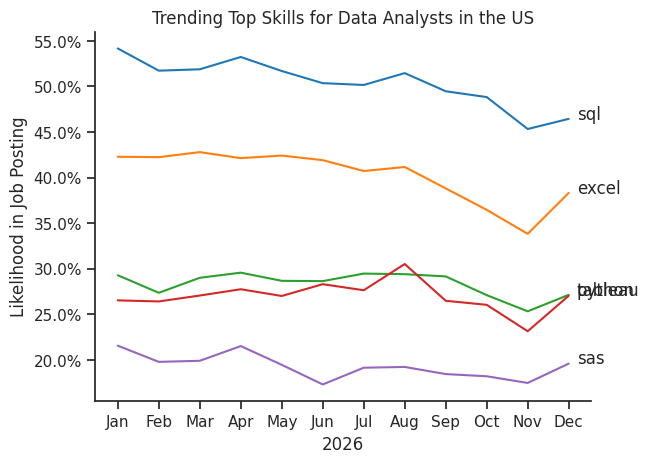

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# --- 1. Data Aggregation & Preparation Section ---
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US['month_no'] = df_DA_US['job_posted_date'].dt.month

df_exploded = df_DA_US.explode('job_skills')

# Identify the top 5 skills based on aggregate counts
top_5_skills = df_exploded['job_skills'].value_counts().head(5).index.tolist()

df_top_skills = df_exploded[df_exploded['job_skills'].isin(top_5_skills)]

df_pivot = df_top_skills.groupby(['month_no', 'job_skills']).size().reset_index(name='skill_count')

monthly_job_counts = df_DA_US.groupby('month_no').size()
df_pivot['total_jobs'] = df_pivot['month_no'].map(monthly_job_counts)
df_pivot['likelihood'] = (df_pivot['skill_count'] / df_pivot['total_jobs']) * 100

# Pivot data so each skill becomes an individual column ordered chronologically
df_plot = df_pivot.pivot(index='month_no', columns='job_skills', values='likelihood')
# Ensure column order matches the aggregate top 5 hierarchy for the plotting index
df_plot = df_plot[top_5_skills]

# Map month numbers to short names for x-axis ticks
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_plot.index = month_labels


# --- 2. Luke's Exact Plotting Section ---
sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()

plt.title('Trending Top Skills for Data Analysts in the US')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2026')
plt.legend().remove()

# Format y-axis to clean percentages
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter())

# Core loop mapping skill name annotations right past the December data point
for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i])

plt.show()

# **PART 3- SALARY ANALYSIS**

# **1. Box Plot: Salary Distributions**

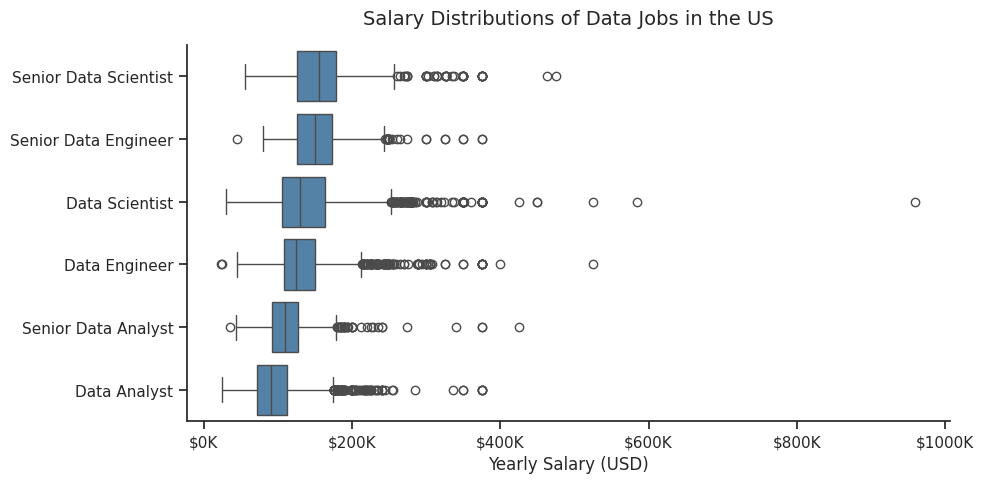

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Filter for jobs in the United States that have valid salary info
df_US = df[(df['job_country'] == 'United States') & (df['salary_year_avg'].notna())].copy()

# Filter for the specific 6 roles needed for the boxplot
target_roles = [
    'Senior Data Scientist', 'Senior Data Engineer',
    'Data Scientist', 'Data Engineer',
    'Senior Data Analyst', 'Data Analyst'
]
df_US_roles = df_US[df_US['job_title_short'].isin(target_roles)].copy()

# Sort order for the box plot matching the hierarchy
df_US_roles['job_title_short'] = pd.Categorical(df_US_roles['job_title_short'], categories=target_roles, ordered=True)

# Formatting tool for thousand markers ($K)
def format_thousands(x, pos):
    return f"${int(x/1000)}K"

formatter = FuncFormatter(format_thousands)

# Build Box Plot
plt.figure(figsize=(10, 5))
sns.set_theme(style='ticks')

sns.boxplot(
    data=df_US_roles,
    x='salary_year_avg',
    y='job_title_short',
    color='#4682B4',  # Steel blue matching Luke's theme
    order=target_roles
)

# Design Formatting
plt.title('Salary Distributions of Data Jobs in the US', fontsize=14, pad=15)
plt.xlabel('Yearly Salary (USD)', fontsize=12)
plt.ylabel('')
plt.gca().xaxis.set_major_formatter(formatter)
sns.despine()
plt.tight_layout()
plt.show()

# **2. Bar Charts: Highest Paid vs. Most In-Demand Skills**

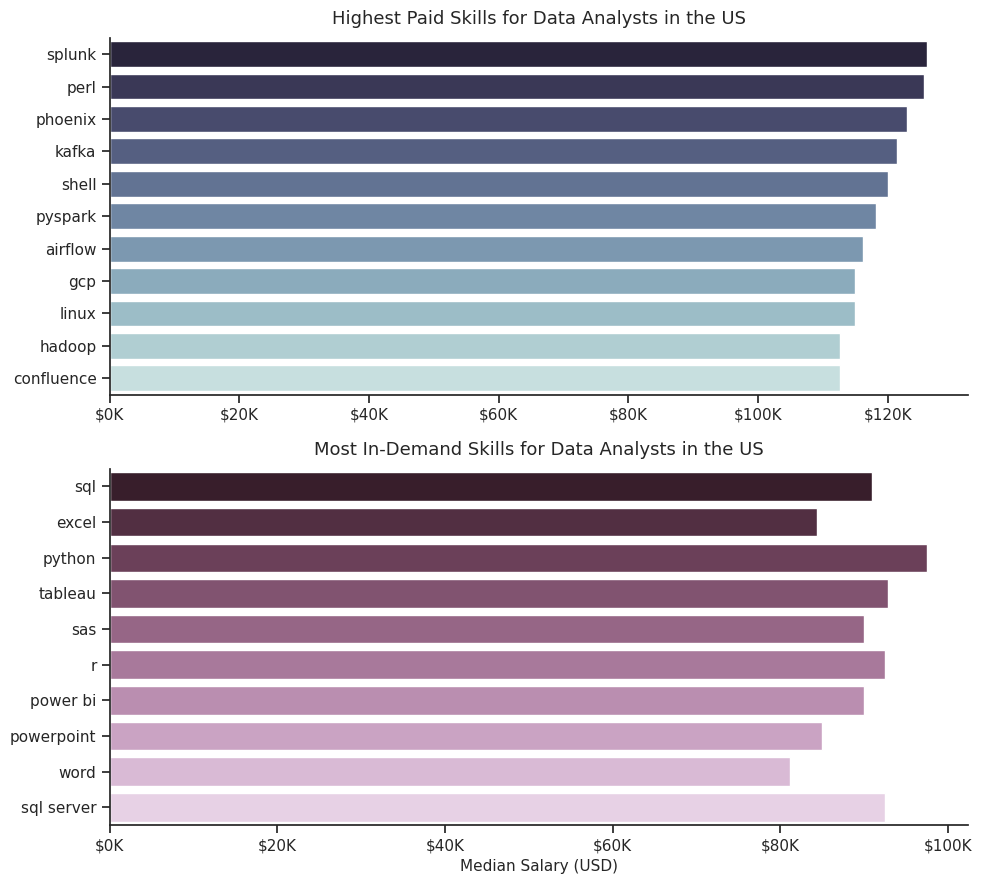

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Filter specifically for Data Analyst roles in the US with salary info
df_DA_US_salary = df[(df['job_country'] == 'United States') &
                     (df['salary_year_avg'].notna()) &
                     (df['job_title_short'] == 'Data Analyst')].copy()

df_DA_exploded = df_DA_US_salary.explode('job_skills')

# Formatter to change axis tick values into '$K'
def format_thousands(x, pos):
    return f"${int(x/1000)}K"

formatter = FuncFormatter(format_thousands)

# A. Data Processing: Highest Paid Skills (Min 10 job mentions threshold)
highest_paid_skills = (
    df_DA_exploded.groupby('job_skills')['salary_year_avg']
    .agg(['median', 'count'])
    .query('count >= 10')
    .sort_values(by='median', ascending=False)
    .head(11)
    .reset_index()
)

# B. Data Processing: Most In-Demand Skills (Top 10 sorted by raw job count)
top_10_demand_skills = df_DA_exploded['job_skills'].value_counts().head(10).index.tolist()
most_indemand_skills = (
    df_DA_exploded[df_DA_exploded['job_skills'].isin(top_10_demand_skills)]
    .groupby('job_skills')['salary_year_avg']
    .median()
    .reindex(top_10_demand_skills)
    .reset_index(name='median')
)

# --- Plotting Subplots ---
fig, axes = plt.subplots(2, 1, figsize=(10, 9))

# Distinct color palettes matching the sequential gradients in the video
colors_top = sns.color_palette("ch:start=.2,rot=-.3_r", n_colors=11)
colors_bottom = sns.color_palette("ch:start=.7,rot=-.1_r", n_colors=10)

# Subplot 1: Highest Paid Skills
sns.barplot(
    data=highest_paid_skills,
    x='median',
    y='job_skills',
    ax=axes[0],
    palette=colors_top,
    hue='job_skills',
    legend=False
)
axes[0].set_title('Highest Paid Skills for Data Analysts in the US', fontsize=13, pad=10)
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(formatter)

# Subplot 2: Most In-Demand Skills
sns.barplot(
    data=most_indemand_skills,
    x='median',
    y='job_skills',
    ax=axes[1],
    palette=colors_bottom,
    hue='job_skills',
    legend=False
)
axes[1].set_title('Most In-Demand Skills for Data Analysts in the US', fontsize=13, pad=10)
axes[1].set_xlabel('Median Salary (USD)', fontsize=11)
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(formatter)

sns.despine()
plt.tight_layout()
plt.show()

# **PART-4 OPTIMAL SKILLS ANALYSIS**

# **Scatter Plot: Most Optimal Skills for Data Analysts in the US**

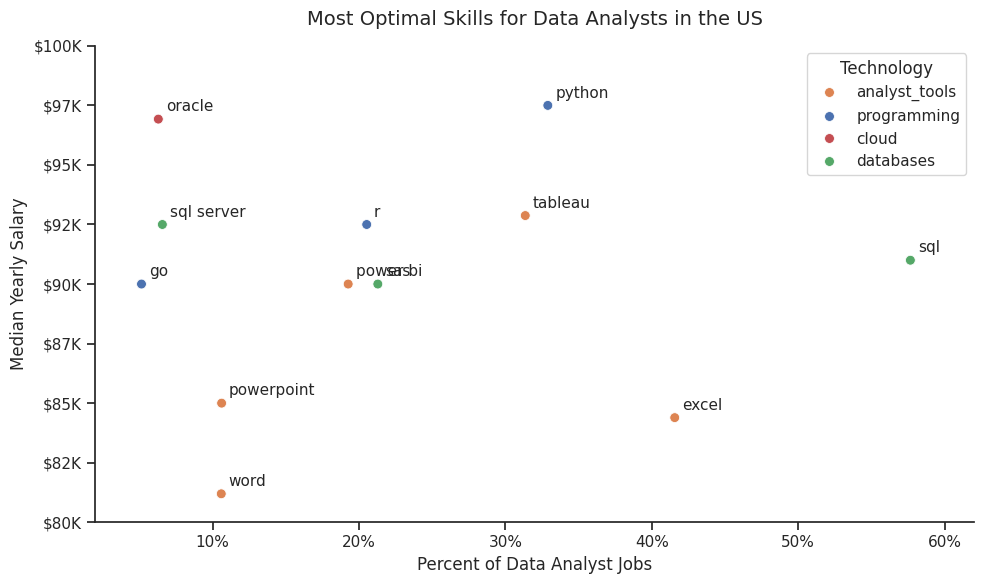

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter, FuncFormatter

# --- 1. Data Cleaning & Preparation ---
# Filter for US Data Analyst positions with non-null salary values
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') &
              (df['job_country'] == 'United States') &
              (df['salary_year_avg'].notna())].copy()

total_us_da_jobs = len(df_DA_US)

# Explode the skills to handle aggregation
df_exploded = df_DA_US.explode('job_skills')

# Aggregating both metrics simultaneously
df_skills = (
    df_exploded.groupby('job_skills')['salary_year_avg']
    .agg(['median', 'count'])
    .reset_index()
)

# Calculate percentage of total Data Analyst jobs requesting each skill
df_skills['job_percentage'] = (df_skills['count'] / total_us_da_jobs) * 100

# Filter out low-frequency skills to match Luke's clean scatter dataset (threshold of count > 10)
df_optimal = df_skills[df_skills['count'] > 10].copy()


# --- 2. Technology Classification Mapping ---
# Dictionary to categorize skills into groups matching the color legend
tech_mapping = {
    'python': 'programming', 'r': 'programming', 'go': 'programming',
    'excel': 'analyst_tools', 'tableau': 'analyst_tools', 'power bi': 'analyst_tools',
    'powerpoint': 'analyst_tools', 'word': 'analyst_tools',
    'sql': 'databases', 'sql server': 'databases', 'sas': 'databases',
    'oracle': 'cloud'
}

# Map classifications and filter down to the specific 12 optimal showcasing points
df_optimal['Technology'] = df_optimal['job_skills'].map(tech_mapping)
df_optimal = df_optimal.dropna(subset=['Technology'])


# --- 3. Visualization Configuration ---
plt.figure(figsize=(10, 6))
sns.set_theme(style='ticks')

# Generate the scatter plot with categorized coloring matching the image legend order
sns.scatterplot(
    data=df_optimal,
    x='job_percentage',
    y='median',
    hue='Technology',
    palette={'programming': '#4c72b0', 'analyst_tools': '#dd8452', 'databases': '#55a868', 'cloud': '#c44e52'},
    s=50
)

# --- 4. Text Annotations Loop ---
# Dynamically label each dot with its corresponding skill name shifted slightly for readability
for _, row in df_optimal.iterrows():
    plt.text(
        row['job_percentage'] + 0.5,
        row['median'] + 200,
        row['job_skills'],
        fontsize=11,
        va='bottom',
        ha='left'
    )


# --- 5. Formatting Axis Ticks & Labels ---
# Format Y-Axis into $K denomination format
def format_thousands(x, pos):
    return f"${int(x/1000)}K"

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_thousands))

# Format X-Axis into clean percentages
plt.gca().xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Visual fine-tuning
plt.title('Most Optimal Skills for Data Analysts in the US', fontsize=14, pad=15)
plt.xlabel('Percent of Data Analyst Jobs', fontsize=12)
plt.ylabel('Median Yearly Salary', fontsize=12)

# Set comfortable padding bounds around data extremes
plt.xlim(2, 62)
plt.ylim(80000, 100000)

sns.despine()
plt.tight_layout()
plt.show()